In [1]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from sentence_transformers import SentenceTransformer
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import emoji
from textblob import TextBlob
import contractions
import num2words
from num2words import num2words
from wordcloud import WordCloud
from collections import Counter
import matplotlib.pyplot as plt

d:\Sem 4\BI\VS Code\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Import "tweets_dataset" using pandas library
df = pd.read_excel("tweets_dataset.xlsx")

# Check for number of rows and columns in "df" dataframe.
df.shape

(27481, 2)

In [3]:
# Display first 5 rows of dataframe.
df.head()

,textID,text
0,cb774db0d1,"I`d have responded, if I were going"
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!
2,088c60f138,my boss is bullying me...
3,9642c003ef,what interview! leave me alone
4,358bd9e861,"Sons of ****, why couldn`t they put them on t..."


In [4]:
# Check for missing values
missing_count = df.isnull().sum()
print(f"Missing values in 'text': {missing_count}")

Missing values in 'text': textID    0
text      1
dtype: int64


In [5]:
# Display row with missing value
df[df['text'].isnull()]

,textID,text
314,fdb77c3752,NaN


In [6]:
# Remove row with missing value
df= df.dropna(subset=['text']).copy()

In [7]:
# Check for duplicatites in dataframe.
total_duplicates = df.duplicated().sum()
print(f"Total duplicate rows (based on all columns): {total_duplicates}")


Total duplicate rows (based on all columns): 0


In [8]:
# Download stopwords and initialize objects
nltk.download(['stopwords', 'wordnet', 'averaged_perceptron_tagger_eng', 'punkt_tab'])
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rojar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\rojar\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\rojar\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\rojar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [9]:
# Define the essential helper function for date standardization, number-to-text conversion, and for lemmatization
def standardize_dates(text):
    # This definition is mandatory to prevent NameError
    return text

def convert_numbers_to_text(text):
    text = re.sub(r'\b(\d+)\b', lambda match: num2words(int(match.group(1))), text)
    return text

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return nltk.corpus.wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return nltk.corpus.wordnet.VERB
    elif treebank_tag.startswith('N'):
        return nltk.corpus.wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return nltk.corpus.wordnet.ADV
    else:
        return nltk.corpus.wordnet.NOUN

In [ ]:
# Define the main text cleaning and normalization function
def clean_and_normalize_text(text):

    # Ensure input is string
    text = str(text)

    # Text clenup
    text = re.sub(r'https?:\/\/\S+', '', text)
    # Remove mentions
    text = re.sub(r'@\w+', '', text)
    # Expand contractions
    text = contractions.fix(text)
    # Convert emojis to text
    text = emoji.demojize(text)
    # Convert numbers to text
    text = convert_numbers_to_text(text)
    # Standardize dates
    text = standardize_dates(text)
    # lowercase
    text = text.lower()
    # Remove non-alphabetic characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    return text

In [ ]:
# Define the tokenization and lemmatization function
def tokenize_and_lemmatize(text):

    # Tokenization
    tokens = word_tokenize(text)

    # Stop word removal
    filtered_tokens = [word for word in tokens if word not in stop_words and len(word) > 1]

    # Pos_tagging
    pos_tokens = nltk.tag.pos_tag(filtered_tokens)

    # Lemmatization
    lemmatized_tokens = []
    for word, tag in pos_tokens:
        wordnet_tag = get_wordnet_pos(tag)
        lemma = lemmatizer.lemmatize(word, pos=wordnet_tag)
        lemmatized_tokens.append(lemma)

    return lemmatized_tokens

In [ ]:
# Define the complete text processing pipeline
def process_text_pipeline(text):

    # 1. Run Cleanup and Normalization
    cleaned_text = clean_and_normalize_text(text)

    # 2. Run Tokenization and Lemmatization
    final_text = tokenize_and_lemmatize(cleaned_text)
    return final_text

df.loc[:, 'text_cleaned'] = df['text'].apply(process_text_pipeline)

# Display first 10 rows of dataframe with a new text_cleaned column
df.head(10)

,textID,text,text_cleaned
0,cb774db0d1,"I`d have responded, if I were going","[id, respond, go]"
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,"[sooo, sad, miss, san, diego]"
2,088c60f138,my boss is bullying me...,"[bos, bully]"
3,9642c003ef,what interview! leave me alone,"[interview, leave, alone]"
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","[son, couldnt, put, release, already, buy]"
5,28b57f3990,http://www.dothebouncy.com/smf - some shameles...,"[shameless, plug, best, ranger, forum, earth]"
6,6e0c6d75b1,2am feedings for the baby are fun when he is a...,"[feeding, baby, fun, smile, coo]"
7,50e14c0bb8,Soooo high,"[soooo, high]"
8,e050245fbd,Both of you,[]
9,fc2cbefa9d,Journey!? Wow... u just became cooler. hehe....,"[journey, wow, become, cool, hehe, possible]"


In [19]:
# Check for missing values
missing_count = df.isnull().sum()
print(f"Missing values in 'text': {missing_count}")

Missing values in 'text': textID          0
text            0
text_cleaned    0
dtype: int64


In [31]:
# Check for empty string values in cleaned_text column
cleaned_text_empty = df[df['text_cleaned'].apply(lambda x: len(x) == 0)]
print(f"Total rows with empty text_cleaned: {len(cleaned_text_empty)}")

# Display the resulting DataFrame containing only the empty strings
cleaned_text_empty[['textID', 'text', 'text_cleaned']]

# There are 70 rows with empty string values in text_cleaned columns.
# This is justified by the fact that original texts were entirely represented by stop_words.

Total rows with empty text_cleaned: 70


,textID,text,text_cleaned
8,e050245fbd,Both of you,[]
328,be8544ffb1,There!,[]
641,5210cc55ae,no,[]
1270,52c5ebcd63,Were have you been?,[]
1385,f0032bffad,what have you been up to ?,[]
...,...,...,...
26109,c02977bde0,**** IT!! _____________,[]
26482,1d05faf04b,and again http://twitpic.com/4wp8l,[]
26513,3ef085ec5a,... same to you!,[]
26584,b4371ac334,is over it. http://plurk.com/p/rp5np,[]


In [32]:
# Remove rows with empty stings in column "text_cleaned".
df_clean = df[df['text_cleaned'].apply(lambda x: len(x) > 0)].copy()

print(f"Original row count: {len(df)}")
print(f"Cleaned row count: {len(df_clean)}")
df_clean.head(10)

Original row count: 27480
Cleaned row count: 27410


,textID,text,text_cleaned
0,cb774db0d1,"I`d have responded, if I were going","[id, respond, go]"
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,"[sooo, sad, miss, san, diego]"
2,088c60f138,my boss is bullying me...,"[bos, bully]"
3,9642c003ef,what interview! leave me alone,"[interview, leave, alone]"
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","[son, couldnt, put, release, already, buy]"
5,28b57f3990,http://www.dothebouncy.com/smf - some shameles...,"[shameless, plug, best, ranger, forum, earth]"
6,6e0c6d75b1,2am feedings for the baby are fun when he is a...,"[feeding, baby, fun, smile, coo]"
7,50e14c0bb8,Soooo high,"[soooo, high]"
9,fc2cbefa9d,Journey!? Wow... u just became cooler. hehe....,"[journey, wow, become, cool, hehe, possible]"
10,2339a9b08b,"as much as i love to be hopeful, i reckon the...","[much, love, hopeful, reckon, chance, minimal,..."


In [33]:
# Load NRC Emotion Lexicon
def load_nrc_lexicon(path):
    nrc = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            word, emotion, value = line.strip().split("\t")
            value = int(value)
            if value == 1:
                nrc.setdefault(word, []).append(emotion)
    return nrc

nrc_lexicon = load_nrc_lexicon("NRC-Emotion-Lexicon-Wordlevel-v0.92.txt")

In [34]:
# Function to assign emotion to a token
def assign_token_emotion(token, lexicon):
    if token in lexicon:
        return lexicon[token][0]    # choose one emotion
    return "none"

# Assign emotions to all tokens
token_emotions_per_sentence = []

for tokens in df_clean['text_cleaned']:
    token_emotions = [assign_token_emotion(t, nrc_lexicon) for t in tokens]
    token_emotions_per_sentence.append(token_emotions)

In [38]:
# Determine dominant emotion for each sentence
sentence_emotions = []

for token_emotions in token_emotions_per_sentence:
    filtered = [e for e in token_emotions if e != "none"]

    if len(filtered) == 0:
        sentence_emotions.append("neutral")
    else:
        dominant = Counter(filtered).most_common(1)[0][0]
        sentence_emotions.append(dominant)

# Add results to dataframe
df_clean["token_emotions"] = token_emotions_per_sentence
df_clean["sentence_emotion"] = sentence_emotions
print(df_clean[["text","text_cleaned","token_emotions", "sentence_emotion"]])

# Convert df_clean to csv
df_clean.to_csv("emotion_detection.csv", index=False)

                                                    text  \
0                    I`d have responded, if I were going   
1          Sooo SAD I will miss you here in San Diego!!!   
2                              my boss is bullying me...   
3                         what interview! leave me alone   
4       Sons of ****, why couldn`t they put them on t...   
...                                                  ...   
27476   wish we could come see u on Denver  husband l...   
27477   I`ve wondered about rake to.  The client has ...   
27478   Yay good for both of you. Enjoy the break - y...   
27479                         But it was worth it  ****.   
27480     All this flirting going on - The ATG smiles...   

                                            text_cleaned  \
0                                      [id, respond, go]   
1                          [sooo, sad, miss, san, diego]   
2                                           [bos, bully]   
3                              [intervi

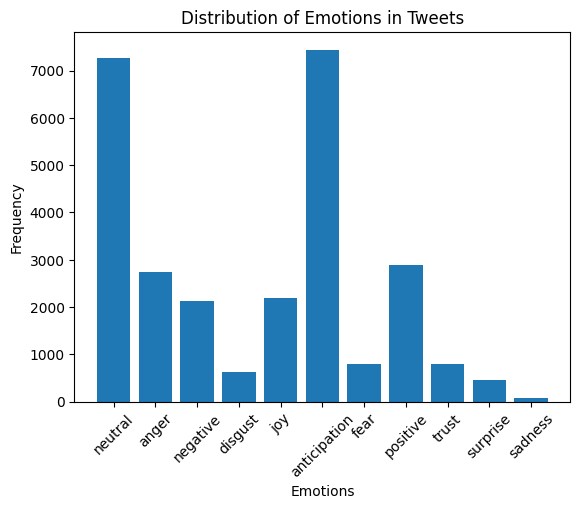

In [42]:
# Visualization of emotion distribution
emotion_counts = Counter(sentence_emotions)
plt.bar(emotion_counts.keys(), emotion_counts.values())
plt.xlabel('Emotions')
plt.ylabel('Frequency')
plt.title('Distribution of Emotions in Tweets')
plt.xticks(rotation=45)
plt.show()

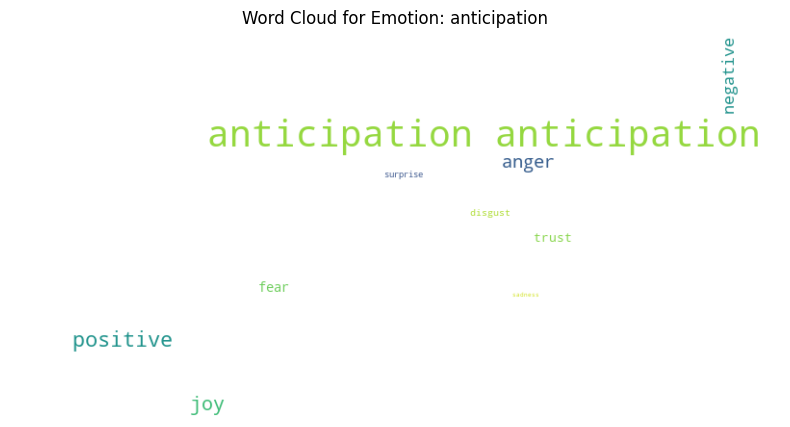

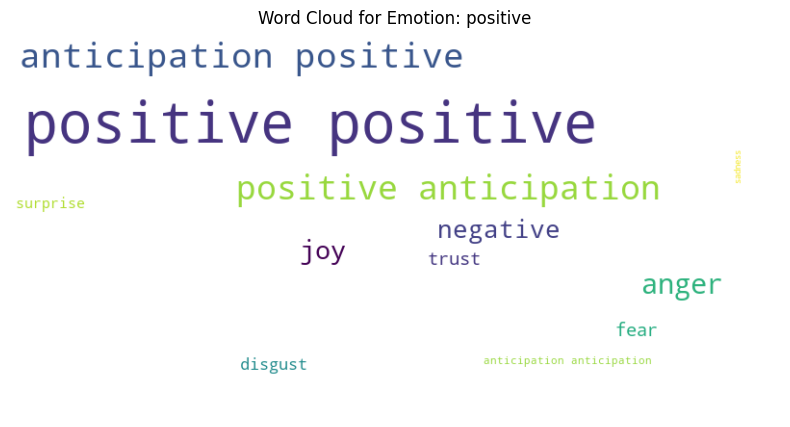

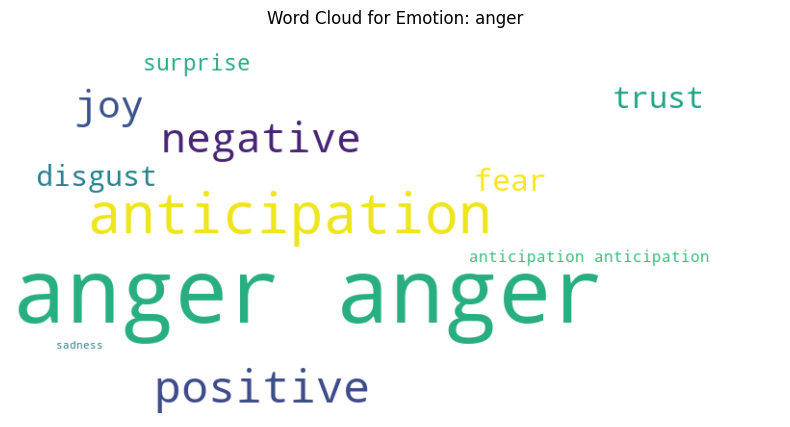

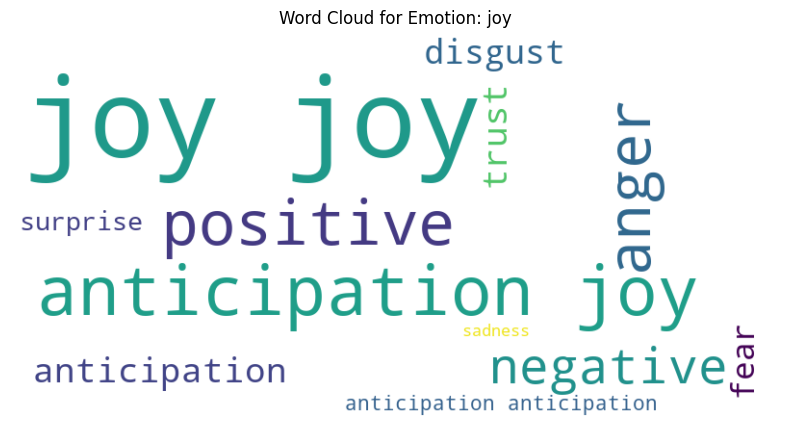

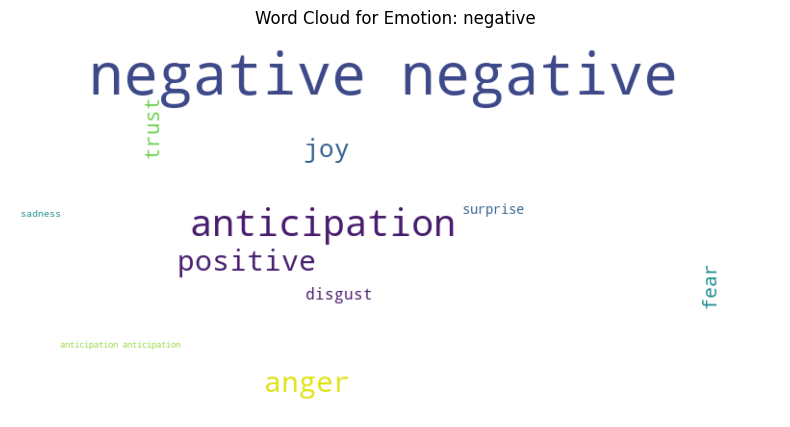

In [51]:
# Visualization of word cloud for top 5 emotions and exclude "neutral"
top_emotions = [emotion for emotion, count in emotion_counts.most_common(10) if emotion != "neutral"][:5]
for emotion in top_emotions:
    all_tokens = []
    for i, row in df_clean.iterrows():
        if row["sentence_emotion"] == emotion:
            # Filter out token-level "none"
            filtered_tokens = [t for t in row["token_emotions"] if t != "none"]
            all_tokens.extend(filtered_tokens)

    wordcloud = WordCloud(width=800, height=400, background_color='white')\
                .generate(' '.join(all_tokens))

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for Emotion: {emotion}')
    plt.show()